In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.chdir('/content/drive/MyDrive/BUDT757/BUDT757 Group 3 Project/')
#

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('Data/enron_spam_data.csv')

Date range

In [ ]:
print("Min Date: ", df['Date'].min())
print("Max Date: ", df['Date'].max())

Min Date:  1999-12-10
Max Date:  2005-09-06


Base line Naive Bayes Split by year

In [ ]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# ---- Clean dataset ----
df = df.dropna(subset=["Message", "Spam/Ham"])

# ---- Text cleaning function ----
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)                  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["Message"].apply(preprocess_text)

# ---- Train-test split based on years ----
cutoff_year = 2002
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop rows where date parsing failed
df = df.dropna(subset=["Date"])

# Extract year
df["Year"] = df["Date"].dt.year


print(df["Year"].value_counts().sort_index())
train_df = df[df["Year"] <= cutoff_year]
test_df  = df[df["Year"] > cutoff_year]

label_map = {"ham": 0, "spam": 1}
train_df["label"] = train_df["Spam/Ham"].map(label_map)
test_df["label"] = test_df["Spam/Ham"].map(label_map)
X_train = train_df["clean_text"]   # or combine Subject + Message
y_train = train_df["label"]

X_test = test_df["clean_text"]
y_test = test_df["label"]
# X_train, X_test, y_train, y_test = train_test_split(
#     df["clean_text"],
#     df["Spam/Ham"],
#     test_size=0.2,
#     random_state=42,
#     stratify=df["Spam/Ham"]
# )

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Year
1999     135
2000    6753
2001    8387
2002    2593
2003     102
2004    5841
2005    9534
Name: count, dtype: int64


/tmp/ipykernel_523/1891138799.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["label"] = train_df["Spam/Ham"].map(label_map)
/tmp/ipykernel_523/1891138799.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["label"] = test_df["Spam/Ham"].map(label_map)


In [ ]:
# ---- Build pipeline ----
nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),     # unigrams + bigrams
        min_df=2,
        max_df=0.9
    )),
    ("nb", MultinomialNB(alpha=1.0))
])

# ---- Train ----
nb_model.fit(X_train, y_train)

# ---- Predict ----
y_pred = nb_model.predict(X_test)

# ---- Evaluate ----
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5231634037604187
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.52      0.69     15477

    accuracy                           0.52     15477
   macro avg       0.50      0.26      0.34     15477
weighted avg       1.00      0.52      0.69     15477



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def get_nb_model_size(model):
    size = 0
    size += model.class_count_.nbytes
    size += model.class_log_prior_.nbytes
    size += model.feature_count_.nbytes
    size += model.feature_log_prob_.nbytes
    return size / (1024 ** 2)  # MB

print("Naive Bayes parameter memory (MB):", get_nb_model_size(nb_model[1]))

Naive Bayes parameter memory (MB): 0.152618408203125


Now we test against a conceptual drift of spam 2021 emails

In [ ]:
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 13.3 MB/s eta 0:00:00


In [ ]:
import py7zr

archive_path = "Data/2021.7z"
extract_path = "spam_data_2021"

with py7zr.SevenZipFile(archive_path, mode='r') as z:
    z.extractall(path=extract_path)

print("Extraction complete.")

Extraction complete.


In [ ]:
import os
import pandas as pd

base_path = "spam_data_2021/2021"

rows = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".txt"):
            file_path = os.path.join(root, file)

            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read()

            # Extract month from folder name
            month = os.path.basename(root)

            rows.append({
                "month": month,
                "filename": file,
                "text": text
            })



In [ ]:
bruce = pd.DataFrame(rows)

bruce.head()

,month,filename,text
0,01,1610749396.1276270_15.txt,Return-Path: <servicebtc@adn.com>\nDelivered-T...
1,01,1610749396.1276270_17.txt,Return-Path: <gutterprotectorco_promotion-bruc...
2,01,1610749396.1276270_19.txt,Return-Path: <ThreeDimensionalRug-bruce=untrou...
3,01,1610749396.1276270_21.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...
4,01,1610749396.1276270_23.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...


In [ ]:
import email
from email import policy
from email.parser import BytesParser
from email.header import decode_header
from io import BytesIO

In [ ]:
def decode_mime_header(value):
    if not value:
        return None

    decoded_parts = decode_header(value)
    decoded_string = ""

    for part, enc in decoded_parts:
        if isinstance(part, bytes):
            decoded_string += part.decode(enc or "utf-8", errors="ignore")
        else:
            decoded_string += part

    return decoded_string

In [ ]:
import codecs

def safe_decode(payload, charset):
    if not payload:
        return ""

    # Normalize invalid charset values
    if not charset:
        charset = "utf-8"

    try:
        codecs.lookup(charset)
    except LookupError:
        charset = "utf-8"

    return payload.decode(charset, errors="ignore")


def extract_body(msg):
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == "text/plain":
                payload = part.get_payload(decode=True)
                return safe_decode(payload, part.get_content_charset())

        for part in msg.walk():
            if part.get_content_type() == "text/html":
                payload = part.get_payload(decode=True)
                return safe_decode(payload, part.get_content_charset())
    else:
        payload = msg.get_payload(decode=True)
        return safe_decode(payload, msg.get_content_charset())

In [ ]:
def parse_email(raw_text):
    msg = BytesParser(policy=policy.default).parse(
        BytesIO(raw_text.encode("utf-8", errors="ignore"))
    )

    return pd.Series({
        "message_id": msg.get("Message-ID"),
        "subject": decode_mime_header(msg.get("Subject")),
        "body": extract_body(msg)
    })

parsed = bruce["text"].apply(parse_email)

bruce_w = pd.concat([bruce, parsed], axis=1)

bruce_w.head()

,month,filename,text,message_id,subject,body
0,01,1610749396.1276270_15.txt,Return-Path: <servicebtc@adn.com>\nDelivered-T...,None,Fordert_besseren_Schlaf,"<HTML><HEAD></HEAD>\n<BODY>\n<P><A href=""https..."
1,01,1610749396.1276270_17.txt,Return-Path: <gutterprotectorco_promotion-bruc...,<0.0.0.36.1D6EB7AB70F86EC.58EA18@mail.rwardtv....,Gutter Protector is about to spill their summe...,<html>\n <head> \n <title>unobserved</title> ...
2,01,1610749396.1276270_19.txt,Return-Path: <ThreeDimensionalRug-bruce=untrou...,<73c7fc7b-f6bf-4bd0-8eaf-d8b07fcc881e@unioncas...,Hilarious and eye-catching rug will be the hig...,
3,01,1610749396.1276270_21.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...,<CADmhhyxkxOK-+JF_Sbw=mgLKnxd3ErYAYuL8R2T6KA00...,I Need Your Assistance,Let me start by introducing myself my name is ...
4,01,1610749396.1276270_23.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...,<CAF+m9ZASY+PbDv0Vmx-Y24pwGTCdd6afjQUs7Jkj4GMY...,OK.........................,"Dear Friend,\n\nAn oil business man made a fix..."


In [ ]:
bruce_w.to_csv('bruce_w.csv', index=False)

In [ ]:
bruce_w = pd.read_csv('bruce_w.csv')

In [ ]:
spam_text = bruce_w['body']

In [ ]:
spam_df = pd.DataFrame(
    {"col": [1] * len(spam_text)},
    index=spam_text.index
)

In [ ]:
spam_text.dropna(inplace=True)
y_pred = nb_model.predict(spam_text)

In [ ]:
print(len(y_pred))
print("Accuracy:", accuracy_score(spam_df[:len(y_pred)], y_pred))

18243
Accuracy: 0.45562681576495095


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9
    )),
    ("lr", LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    ))
])

In [ ]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=2,
                                 ngram_range=(1, 2))),
                ('lr',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
lr_clean_pred = lr_model.predict(X_test)
lr_clean_proba = lr_model.predict_proba(X_test)

lr_clean_acc = accuracy_score(y_test, lr_clean_pred)
lr_clean_f1 = f1_score(y_test, lr_clean_pred)
lr_clean_conf = lr_clean_proba.max(axis=1).mean()

print("LR Clean Accuracy:", lr_clean_acc)

LR Clean Accuracy: 0.21063513600827033


In [ ]:
y_pred = lr_model.predict(spam_text)

In [ ]:
print("Accuracy:", accuracy_score(spam_df[:len(y_pred)], y_pred))


Accuracy: 0.04988214657676917


# DistilBert

In [ ]:
!pip install transformers datasets accelerate evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import random

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
import pandas as pd

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df["Year"] = df["Date"].dt.year

cutoff_year = 2002
train_df = df[df["Year"] <= cutoff_year]
test_df  = df[df["Year"] > cutoff_year]

train_df["text"] = train_df["Subject"].fillna("") + " " + train_df["Message"].fillna("")
test_df["text"]  = test_df["Subject"].fillna("") + " " + test_df["Message"].fillna("")

# Convert labels to numeric
label_map = {"ham": 0, "spam": 1}
train_df["label"] = train_df["Spam/Ham"].map(label_map)
test_df["label"] = test_df["Spam/Ham"].map(label_map)

print(len(train_df), len(test_df))

17868 15477


/tmp/ipython-input-1350/3107055652.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["text"] = train_df["Subject"].fillna("") + " " + train_df["Message"].fillna("")
/tmp/ipython-input-1350/3107055652.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["text"]  = test_df["Subject"].fillna("") + " " + test_df["Message"].fillna("")
/tmp/ipython-input-1350/3107055652.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
test_dataset  = Dataset.from_pandas(test_df[["text", "label"]])

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/17868 [00:00<?, ? examples/s]

Map:   0%|          | 0/15477 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainingArguments, Trainer
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": (predictions == labels).mean()
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,  # Start small
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    seed=42
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.013368,0.575950,0.877043
2,0.006092,1.762763,0.713510


TrainOutput(global_step=2234, training_loss=0.02537234020798785, metrics={'train_runtime': 1220.2757, 'train_samples_per_second': 29.285, 'train_steps_per_second': 1.831, 'total_flos': 2366927479185408.0, 'train_loss': 0.02537234020798785, 'epoch': 2.0})

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 1.7627633810043335, 'eval_accuracy': 0.7135103702267881, 'eval_runtime': 136.9665, 'eval_samples_per_second': 112.998, 'eval_steps_per_second': 7.067, 'epoch': 2.0}


In [ ]:
print("GPU memory allocated:",
      torch.cuda.memory_allocated() / 1024**3, "GB")

GPU memory allocated: 0.7882428169250488 GB


In [ ]:
model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert_spam_model")
tokenizer = AutoTokenizer.from_pretrained("bert_spam_model")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
# Convert to list of clean strings
spam_text_clean = (
    spam_text
    .dropna()              # remove missing values
    .astype(str)           # ensure all entries are strings
    .tolist()
)

In [ ]:
import torch

import torch
from math import ceil

batch_size = 32
all_preds = []

model.eval()

for i in range(0, len(spam_text_clean), batch_size):
    batch_texts = spam_text_clean[i:i+batch_size]

    encodings = tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**encodings)
        preds = torch.argmax(outputs.logits, dim=1)

    all_preds.extend(preds.cpu().numpy())

y_pred_bert = all_preds

In [ ]:
from sklearn.metrics import accuracy_score
print(len(bruce_w['body']))
print(len(y_pred_bert))
print("Accuracy:", accuracy_score(spam_df[:len(y_pred_bert)], y_pred_bert))

18607
18243
Accuracy: 0.37493833251110015


In [ ]:
model.save_pretrained("bert_spam_model")
tokenizer.save_pretrained("bert_spam_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_spam_model/tokenizer_config.json', 'bert_spam_model/tokenizer.json')

# Evasion

In [ ]:
import random
import re

def misspell_attack(text):
    replacements = {
        "free": "fr33",
        "click": "cl1ck",
        "offer": "0ffer",
        "money": "m0ney",
        "win": "w1n"
    }
    for k, v in replacements.items():
        text = re.sub(rf"\b{k}\b", v, text, flags=re.IGNORECASE)
    return text


def case_attack(text):
    return "".join(
        c.upper() if random.random() > 0.5 else c.lower()
        for c in text
    )


def padding_attack(text):
    padding = " meeting schedule project discussion quarterly analysis update"
    return text + padding


def special_char_attack(text):
    return re.sub(r"[aeiou]", lambda m: m.group(0) + "!", text)

In [ ]:
subset_size = 1000

test_subset = test_df.sample(subset_size, random_state=42).copy()

attacks = {
    "clean": lambda x: x,
    "misspell": misspell_attack,
    "case": case_attack,
    "padding": padding_attack,
    "special_char": special_char_attack
}

attacked_sets = {}

for name, attack_fn in attacks.items():
    attacked_sets[name] = test_subset["text"].apply(attack_fn)

In [ ]:
nb_results = {}

for name, texts in attacked_sets.items():
    preds = nb_model.predict(texts)
    probs = nb_model.predict_proba(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)
    confidence = probs.max(axis=1).mean()

    nb_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

nb_results

{'clean': {'accuracy': 0.537,
  'f1': 0.6987638256343527,
  'confidence': np.float64(0.7574612756098777)},
 'misspell': {'accuracy': 0.51,
  'f1': 0.6754966887417219,
  'confidence': np.float64(0.7512060436689417)},
 'case': {'accuracy': 0.537,
  'f1': 0.6987638256343527,
  'confidence': np.float64(0.7574612756098777)},
 'padding': {'accuracy': 0.282,
  'f1': 0.43993759750390016,
  'confidence': np.float64(0.8285568706228732)},
 'special_char': {'accuracy': 0.002,
  'f1': 0.003992015968063872,
  'confidence': np.float64(0.8290957709696144)}}

In [ ]:
lr_results = {}

for name, texts in attacked_sets.items():
    preds = lr_model.predict(texts)
    probs = lr_model.predict_proba(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)
    confidence = probs.max(axis=1).mean()

    lr_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

lr_results

{'clean': {'accuracy': 0.239,
  'f1': 0.38579499596448746,
  'confidence': np.float64(0.75766843735901)},
 'misspell': {'accuracy': 0.137,
  'f1': 0.24098504837291118,
  'confidence': np.float64(0.767989960022792)},
 'case': {'accuracy': 0.239,
  'f1': 0.38579499596448746,
  'confidence': np.float64(0.75766843735901)},
 'padding': {'accuracy': 0.124,
  'f1': 0.2206405693950178,
  'confidence': np.float64(0.8214273816595857)},
 'special_char': {'accuracy': 0.001,
  'f1': 0.001998001998001998,
  'confidence': np.float64(0.877809114291387)}}

In [ ]:
import torch
import numpy as np

def evaluate_bert(texts):
    encodings = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**encodings)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

    preds = torch.argmax(probs, dim=1).cpu().numpy()
    confidence = probs.max(dim=1).values.mean().item()

    return preds, confidence

In [ ]:
bert_results = {}

for name, texts in attacked_sets.items():
    preds, confidence = evaluate_bert(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)

    bert_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

bert_results

{'clean': {'accuracy': 0.711,
  'f1': 0.831092928112215,
  'confidence': 0.9721149206161499},
 'misspell': {'accuracy': 0.696,
  'f1': 0.8207547169811321,
  'confidence': 0.9711006283760071},
 'case': {'accuracy': 0.711,
  'f1': 0.831092928112215,
  'confidence': 0.972115159034729},
 'padding': {'accuracy': 0.566,
  'f1': 0.722860791826309,
  'confidence': 0.9742174744606018},
 'special_char': {'accuracy': 0.947,
  'f1': 0.9727786337955829,
  'confidence': 0.9784753918647766}}

In [ ]:
import pandas as pd

def build_comparison_table(nb_results, lr_results, bert_results):
    rows = []

    attacks = nb_results.keys()

    for attack in attacks:
        rows.append({
            "Attack": attack,
            "NB Accuracy": nb_results[attack]["accuracy"],
            "LR Accuracy": lr_results[attack]["accuracy"],
            "BERT Accuracy": bert_results[attack]["accuracy"],
            "NB Confidence": nb_results[attack]["confidence"],
            "LR Confidence": lr_results[attack]["confidence"],
            "BERT Confidence": bert_results[attack]["confidence"],
        })

    return pd.DataFrame(rows)

In [ ]:
comparison_table = build_comparison_table(
    nb_results,
    lr_results,
    bert_results
)

comparison_table

,Attack,NB Accuracy,LR Accuracy,BERT Accuracy,NB Confidence,LR Confidence,BERT Confidence
0,clean,0.537,0.239,0.711,0.757461,0.757668,0.972115
1,misspell,0.510,0.137,0.696,0.751206,0.767990,0.971101
2,case,0.537,0.239,0.711,0.757461,0.757668,0.972115
3,padding,0.282,0.124,0.566,0.828557,0.821427,0.974217
4,special_char,0.002,0.001,0.947,0.829096,0.877809,0.978475


In [ ]:
clean_nb = nb_results["clean"]["accuracy"]
clean_bert = bert_results["clean"]["accuracy"]
clean_logit = lr_results["clean"]["accuracy"]
for attack in nb_results:
    print("Attack:", attack)
    print("NB Δ:", clean_nb - nb_results[attack]["accuracy"])
    print("BERT Δ:", clean_bert - bert_results[attack]["accuracy"])
    print("LR Δ:", clean_logit - lr_results[attack]["accuracy"])
    print()

Attack: clean
NB Δ: 0.0
BERT Δ: 0.0
LR Δ: 0.0

Attack: misspell
NB Δ: 0.027000000000000024
BERT Δ: 0.015000000000000013
LR Δ: 0.10199999999999998

Attack: case
NB Δ: 0.0
BERT Δ: 0.0
LR Δ: 0.0

Attack: padding
NB Δ: 0.25500000000000006
BERT Δ: 0.14500000000000002
LR Δ: 0.11499999999999999

Attack: special_char
NB Δ: 0.535
BERT Δ: -0.236
LR Δ: 0.238



# Confidence Shift with concept drift

#### Naive Bayes

In [ ]:
# Validation predictions
nb_val_proba = nb_model.predict_proba(X_test)
nb_val_conf = nb_val_proba.max(axis=1)

# Test predictions
nb_test_proba = nb_model.predict_proba(spam_text)
nb_test_conf = nb_test_proba.max(axis=1)

print("Validation mean confidence:", nb_val_conf.mean())
print("Test mean confidence:", nb_test_conf.mean())
print("Confidence shift:", nb_test_conf.mean() - nb_val_conf.mean())

Validation mean confidence: 0.7614659166080181
Test mean confidence: 0.7297306956883565
Confidence shift: -0.03173522091966163


In [ ]:
import numpy as np

def summarize_conf(conf):
    return {
        "mean": np.mean(conf),
        "std": np.std(conf),
        "min": np.min(conf),
        "25%": np.percentile(conf, 25),
        "50%": np.median(conf),
        "75%": np.percentile(conf, 75),
        "max": np.max(conf),
    }

print("Validation confidence stats:", summarize_conf(nb_val_conf))
print("Test confidence stats:", summarize_conf(nb_test_conf))

Validation confidence stats: {'mean': np.float64(0.7744515822233208), 'std': np.float64(0.13976071177316532), 'min': np.float64(0.5000501158881104), '25%': np.float64(0.6583650294068948), '50%': np.float64(0.800611505655837), '75%': np.float64(0.8970272208868543), 'max': np.float64(0.997171643342601)}
Test confidence stats: {'mean': np.float64(0.8374729464167342), 'std': np.float64(0.10882432045782067), 'min': np.float64(0.5000186336661168), '25%': np.float64(0.7968069851114385), '50%': np.float64(0.8619355440536118), '75%': np.float64(0.9175412210015423), 'max': np.float64(0.995232278580888)}


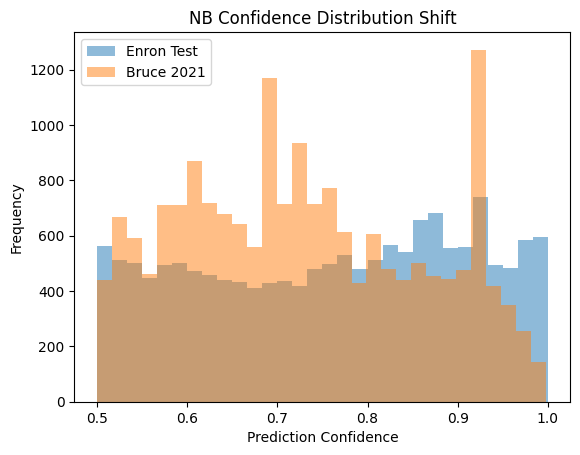

In [ ]:
import matplotlib.pyplot as plt

plt.hist(nb_val_conf, bins=30, alpha=0.5, label="Enron Test")
plt.hist(nb_test_conf, bins=30, alpha=0.5, label="Bruce 2021")
plt.legend()
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("NB Confidence Distribution Shift")
plt.show()

In [ ]:
from sklearn.metrics import brier_score_loss

val_brier = brier_score_loss(y_test, val_proba[:,1])
test_brier = brier_score_loss(spam_df[:len(test_proba)], test_proba[:,1])

print("Validation Brier:", val_brier)
print("Test Brier:", test_brier)

Validation Brier: 0.540074394881143
Test Brier: 0.6992297686881503


#### Logistic Regression

In [ ]:
# Validation predictions
lr_val_proba = lr_model.predict_proba(X_test)
lr_val_conf = lr_val_proba.max(axis=1)

# Test predictions
lr_test_proba = lr_model.predict_proba(spam_text)
lr_test_conf = lr_test_proba.max(axis=1)

print("Validation mean confidence:", lr_val_conf.mean())
print("Test mean confidence:", lr_test_conf.mean())
print("Confidence shift:", lr_test_conf.mean() - lr_val_conf.mean())

Validation mean confidence: 0.7744515822233208
Test mean confidence: 0.8374729464167342
Confidence shift: 0.06302136419341342


In [ ]:
print("Validation confidence stats:", summarize_conf(lr_val_conf))
print("Test confidence stats:", summarize_conf(lr_test_conf))

Validation confidence stats: {'mean': np.float64(0.7744515822233208), 'std': np.float64(0.13976071177316532), 'min': np.float64(0.5000501158881104), '25%': np.float64(0.6583650294068948), '50%': np.float64(0.800611505655837), '75%': np.float64(0.8970272208868543), 'max': np.float64(0.997171643342601)}
Test confidence stats: {'mean': np.float64(0.8374729464167342), 'std': np.float64(0.10882432045782067), 'min': np.float64(0.5000186336661168), '25%': np.float64(0.7968069851114385), '50%': np.float64(0.8619355440536118), '75%': np.float64(0.9175412210015423), 'max': np.float64(0.995232278580888)}


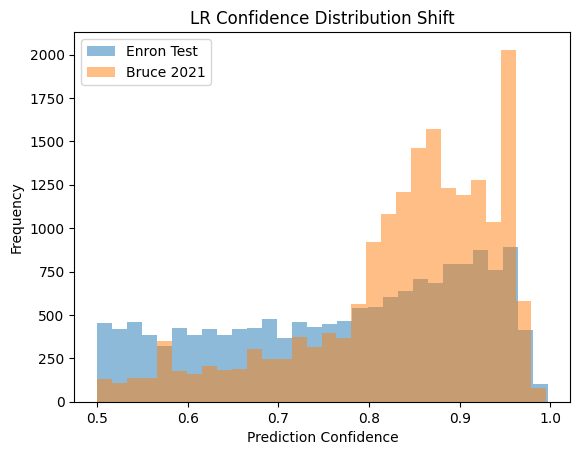

In [ ]:
import matplotlib.pyplot as plt

plt.hist(lr_val_conf, bins=30, alpha=0.5, label="Enron Test")
plt.hist(lr_test_conf, bins=30, alpha=0.5, label="Bruce 2021")
plt.legend()
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("LR Confidence Distribution Shift")
plt.show()

In [ ]:
from sklearn.metrics import brier_score_loss

lr_val_brier = brier_score_loss(y_test, lr_val_proba[:,1])
lr_test_brier = brier_score_loss(spam_df[:len(lr_test_proba)], lr_test_proba[:,1])

print("Validation Brier:", val_brier)
print("Test Brier:", test_brier)

Validation Brier: 0.11841939284888979
Test Brier: 0.6660639456155989


#### DistilBert

In [ ]:
import torch
import numpy as np
from torch.nn.functional import softmax

def get_confidence(model, dataloader, device):
    model.eval()
    confidences = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)

            logits = outputs.logits
            probs = softmax(logits, dim=1)

            batch_conf = probs.max(dim=1).values
            confidences.extend(batch_conf.cpu().numpy())

    return np.array(confidences)

In [ ]:
from torch.utils.data import DataLoader


X_val = X_test.copy().reset_index(drop=True)
X_test_final = spam_text.copy().reset_index(drop=True)

class SpamDataset(torch.utils.data.Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts.iloc[idx]

def collate_fn(batch):
    encoding = tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    return {
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"]
    }

val_dataset = SpamDataset(X_val)
test_dataset = SpamDataset(X_test_final)

val_dataloader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=32, collate_fn=collate_fn)

bert_val_conf = get_confidence(model, val_dataloader, device)
bert_test_conf = get_confidence(model, test_dataloader, device)

print("Validation mean confidence:", bert_val_conf.mean())
print("Test mean confidence:", bert_test_conf.mean())
print("Confidence shift:", bert_test_conf.mean() - bert_val_conf.mean())

Validation mean confidence: 0.97686964
Test mean confidence: 0.95526224
Confidence shift: -0.021607399


In [ ]:
print("Validation stats:", summarize_conf(bert_val_conf))
print("Test stats:", summarize_conf(bert_test_conf))

Validation stats: {'mean': np.float32(0.97686964), 'std': np.float32(0.07332915), 'min': np.float32(0.50012904), '25%': np.float32(0.9963045), '50%': np.float32(0.99865615), '75%': np.float32(0.9990013), 'max': np.float32(0.9999298)}
Test stats: {'mean': np.float32(0.95526224), 'std': np.float32(0.10148974), 'min': np.float32(0.50134945), '25%': np.float32(0.9780877), '50%': np.float32(0.9983133), '75%': np.float32(0.99957687), 'max': np.float32(0.9999496)}


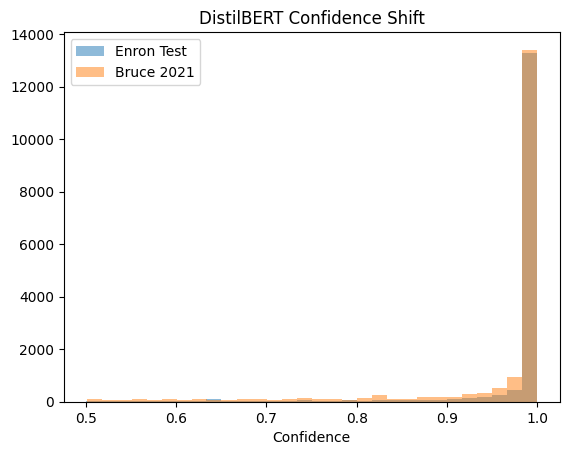

In [ ]:
import matplotlib.pyplot as plt

plt.hist(bert_val_conf, bins=30, alpha=0.5, label="Enron Test")
plt.hist(bert_test_conf, bins=30, alpha=0.5, label="Bruce 2021")
plt.legend()
plt.xlabel("Confidence")
plt.title("DistilBERT Confidence Shift")
plt.show()

In [ ]:
def get_probabilities(model, dataloader, device):
    model.eval()
    probs = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)

            logits = outputs.logits
            probabilities = torch.softmax(logits, dim=1)[:, 1]

            probs.extend(probabilities.cpu().numpy())

    return np.array(probs)

In [ ]:
from sklearn.metrics import brier_score_loss

val_probs = get_probabilities(model, val_dataloader, device)
test_probs = get_probabilities(model, test_dataloader, device)



In [ ]:
val_brier = brier_score_loss(y_test, val_probs)
test_brier = brier_score_loss(spam_df[:len(test_probs)], test_probs)

print("Validation Brier score:", val_brier)
print("Test Brier score:", test_brier)
print("Brier shift:", test_brier - val_brier)

Validation Brier score: 0.11841939284888979
Test Brier score: 0.6660639456155989
Brier shift: 0.5476445527667091
